### WEEK 6
#### Predicting 'y' - Using Categorical Data
#### Yiscah Mark - 4/22/2026

##### Getting the dataset.

In [1]:
!pip install gdown
import gdown

url = 'https://drive.google.com/file/d/1AytxJlBLFGC3D-gXsRPfYBg3g6tvINac/view?usp=sharing'
gdown.download(url, 'eda_classification', quiet=False)


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


Downloading...
From: https://drive.google.com/uc?id=1AytxJlBLFGC3D-gXsRPfYBg3g6tvINac
To: /home/1bb32383-9cd3-4863-8b90-d3cb84c7db6b/eda_classification
100%|██████████| 1.92M/1.92M [00:00<00:00, 29.8MB/s]


'eda_classification'

##### Opening the dataset and printing the heading to wee how the data can be cleaned.

In [2]:
import pandas as pd
data = pd.read_csv('eda_classification')
data.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,y
0,-17.933519,Jun,6.559220,-14.452810,-4.732855,0.381673,2.563194,"($1,306.52)",-89.394348,-28.454044,-16.201298,-0.01%,0.217010,tesla,thurday,9.729891,-0.786431,small,1
1,-37.214754,July,10.774930,-15.384004,-0.077339,10.983774,-15.210206,($24.86),153.032652,-32.557736,69.675903,0.00%,-3.584908,Toyota,thur,35.727926,-0.985552,small,0
2,0.330441,Aug,-19.609972,-9.167911,2.064124,12.071688,12.506141,($110.85),-141.437276,-20.794952,55.042604,0.00%,-3.991366,bmw,wednesday,-9.283523,-3.394718,small,1
3,-13.709765,Aug,-8.011390,6.759264,1.727615,-1.768382,24.039733,($324.43),51.039653,-7.046908,-31.424419,0.01%,7.908897,Toyota,wed,-2.891882,-2.690222,small,0
4,-4.202598,May,7.076210,-26.004919,-4.269696,-3.414224,2.115989,"$1,213.37",-31.046700,19.061182,-31.525515,-0.01%,0.846719,Honda,wednesday,25.497480,3.516801,small,1


##### Checking for missing values.

In [3]:
# Drop rows where any column has a missing value
df_clean = data.dropna()

# Verify that nulls are gone
print("New Null Counts:")
print(df_clean.isnull().sum())

# Check how many rows you have left
print(f"\nOriginal rows: {len(data)}")
print(f"Rows after cleaning: {len(df_clean)}")

New Null Counts:
x0     0
x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
x11    0
x12    0
x13    0
x14    0
x15    0
x16    0
x17    0
y      0
dtype: int64

Original rows: 9999
Rows after cleaning: 9968


##### Since there are only a few missing data, I will remove those rows. The check is to make sure the columns were removed.

In [4]:
# Count missing values per column
null_counts = data.isnull().sum()
print("Null counts per column:")
print(null_counts)

Null counts per column:
x0     3
x1     0
x2     4
x3     3
x4     2
x5     2
x6     0
x7     3
x8     1
x9     0
x10    3
x11    2
x12    4
x13    1
x14    2
x15    0
x16    1
x17    0
y      0
dtype: int64


In [5]:
df_clean.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,y
0,-17.933519,Jun,6.559220,-14.452810,-4.732855,0.381673,2.563194,"($1,306.52)",-89.394348,-28.454044,-16.201298,-0.01%,0.217010,tesla,thurday,9.729891,-0.786431,small,1
1,-37.214754,July,10.774930,-15.384004,-0.077339,10.983774,-15.210206,($24.86),153.032652,-32.557736,69.675903,0.00%,-3.584908,Toyota,thur,35.727926,-0.985552,small,0
2,0.330441,Aug,-19.609972,-9.167911,2.064124,12.071688,12.506141,($110.85),-141.437276,-20.794952,55.042604,0.00%,-3.991366,bmw,wednesday,-9.283523,-3.394718,small,1
3,-13.709765,Aug,-8.011390,6.759264,1.727615,-1.768382,24.039733,($324.43),51.039653,-7.046908,-31.424419,0.01%,7.908897,Toyota,wed,-2.891882,-2.690222,small,0
4,-4.202598,May,7.076210,-26.004919,-4.269696,-3.414224,2.115989,"$1,213.37",-31.046700,19.061182,-31.525515,-0.01%,0.846719,Honda,wednesday,25.497480,3.516801,small,1


#### Column x7 has dollar symbols and parenthesis. I removed them.

In [6]:
# .loc ensures you are modifying the actual dataframe, not a copy
# The ":" means "apply to all rows"
df_clean.loc[:, 'x7'] = df_clean['x7'].replace('[\$,()]', '', regex=True).astype(float)
df_clean.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,y
0,-17.933519,Jun,6.559220,-14.452810,-4.732855,0.381673,2.563194,1306.52,-89.394348,-28.454044,-16.201298,-0.01%,0.217010,tesla,thurday,9.729891,-0.786431,small,1
1,-37.214754,July,10.774930,-15.384004,-0.077339,10.983774,-15.210206,24.86,153.032652,-32.557736,69.675903,0.00%,-3.584908,Toyota,thur,35.727926,-0.985552,small,0
2,0.330441,Aug,-19.609972,-9.167911,2.064124,12.071688,12.506141,110.85,-141.437276,-20.794952,55.042604,0.00%,-3.991366,bmw,wednesday,-9.283523,-3.394718,small,1
3,-13.709765,Aug,-8.011390,6.759264,1.727615,-1.768382,24.039733,324.43,51.039653,-7.046908,-31.424419,0.01%,7.908897,Toyota,wed,-2.891882,-2.690222,small,0
4,-4.202598,May,7.076210,-26.004919,-4.269696,-3.414224,2.115989,1213.37,-31.046700,19.061182,-31.525515,-0.01%,0.846719,Honda,wednesday,25.497480,3.516801,small,1


#### Once I encoded the categorical columns I saw that some of the days of the week were written short hand. I made a dictionary to map them the shorthand onto the real day, but the days had caps issues. First I changed it in the dictionary, then i ended up lowercasing everything. The last issue was a Thursday that was spelled wrong, I just added it to the dictionary and the problem was solved.

In [7]:
# .loc syntax: [all rows, column name]
df_clean.loc[:, 'x14'] = df_clean['x14'].str.lower()

# Verify the change
print(df_clean['x14'].head())

0      thurday
1         thur
2    wednesday
3          wed
4    wednesday
Name: x14, dtype: object


In [8]:
# 1. Standardize casing to lowercase
df_clean.loc[:, 'x14'] = df_clean['x14'].str.lower()

# 2. Map shorthand and typos to full names
day_mapping = {
    'mon': 'monday',
    'tue': 'tuesday',
    'wed': 'wednesday',
    'thu': 'thursday',
    'thur': 'thursday',
    'thurday': 'thursday',
    'fri': 'friday',
    'sat': 'saturday',
    'sun': 'sunday'
}

df_clean.loc[:, 'x14'] = df_clean['x14'].replace(day_mapping)

# 3. Explicitly drop any remaining null objects in this column
df_clean = df_clean.dropna(subset=['x14'])

# 4. Verification
print("Unique days in x14:")
print(df_clean['x14'].unique())

Unique days in x14:
['thursday' 'wednesday' 'tuesday' 'monday' 'friday']


#### I once again created a dictionary to map all the typos, and long names to a consistent form of each month name.

In [9]:
# 1. Force everything to lowercase and remove periods (fixes 'sept.')
df_clean.loc[:, 'x1'] = df_clean['x1'].str.lower().str.replace('.', '', regex=False)

# 2. Map the specific typos to the correct values
# This fixes 'dev' -> 'dec' and ensures 'january'/'sept' match your other shorthand months
month_mapping = {
    'dev': 'dec',
    'january': 'jan',
    'sept': 'sep',
    'july': 'jul'
}

df_clean.loc[:, 'x1'] = df_clean['x1'].replace(month_mapping)

# 3. Drop any actual nulls that existed in the original data
df_clean = df_clean.dropna(subset=['x1'])

# 4. Verify the results
print("Final unique months in x1:")
print(df_clean['x1'].unique())

Final unique months in x1:
['jun' 'jul' 'aug' 'may' 'apr' 'sep' 'oct' 'dec' 'mar' 'nov' 'feb' 'jan']


In [10]:
df_clean.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,y
0,-17.933519,jun,6.559220,-14.452810,-4.732855,0.381673,2.563194,1306.52,-89.394348,-28.454044,-16.201298,-0.01%,0.217010,tesla,thursday,9.729891,-0.786431,small,1
1,-37.214754,jul,10.774930,-15.384004,-0.077339,10.983774,-15.210206,24.86,153.032652,-32.557736,69.675903,0.00%,-3.584908,Toyota,thursday,35.727926,-0.985552,small,0
2,0.330441,aug,-19.609972,-9.167911,2.064124,12.071688,12.506141,110.85,-141.437276,-20.794952,55.042604,0.00%,-3.991366,bmw,wednesday,-9.283523,-3.394718,small,1
3,-13.709765,aug,-8.011390,6.759264,1.727615,-1.768382,24.039733,324.43,51.039653,-7.046908,-31.424419,0.01%,7.908897,Toyota,wednesday,-2.891882,-2.690222,small,0
4,-4.202598,may,7.076210,-26.004919,-4.269696,-3.414224,2.115989,1213.37,-31.046700,19.061182,-31.525515,-0.01%,0.846719,Honda,wednesday,25.497480,3.516801,small,1


#### I checked to see if there were any typos or repeats of car names. There were no repeats, but some names were capitalized and some not so I just made everything lowercase so that it was uniform.

In [11]:
df_clean.loc[:, 'x13'] = df_clean['x13'].str.lower()
print("Unique car names in x13:")
print(df_clean['x13'].unique())

Unique car names in x13:
['tesla' 'toyota' 'bmw' 'honda' 'ford' 'volkswagon' 'chrystler' 'nissan'
 'mercades' 'chevrolet']


#### In this column I converted the percent to a decimal. I noticed two values at zero, it could be a filler or a real value so the next thing I did was get the count of all the unique values. Since there are negative and positive very precise values that form a bell curved shape around the mean, 0.0 it is safe to assume that it is the actual value not a filler.

In [12]:
# 1. Strip the percent sign and convert to float
df_clean.loc[:, 'x11'] = df_clean['x11'].str.replace('%', '', regex=False).astype(float)

# 2. (Optional) Convert to decimal format
# Many data scientists prefer 0.05 over 5.0 for percentages
df_clean.loc[:, 'x11'] = df_clean['x11'] / 100

# 3. Verify the transformation
print(df_clean['x11'].dtype)
print(df_clean['x11'].head())

# This shows every unique value and how many times it appears
print(df_clean['x11'].value_counts())

object
0   -0.0001
1       0.0
2       0.0
3    0.0001
4   -0.0001
Name: x11, dtype: object
x11
 0.0       3906
-0.0001    2400
 0.0001    2354
 0.0002     578
-0.0002     578
-0.0003      72
 0.0003      72
-0.0004       4
 0.0004       4
Name: count, dtype: int64


#### A quick check shows that there are no spelling errors in the "size" column.

In [13]:
print("Unique car names in x17:")
print(df_clean['x17'].unique())

Unique car names in x17:
['small' 'medium' 'large']


In [14]:
df_clean.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,y
0,-17.933519,jun,6.559220,-14.452810,-4.732855,0.381673,2.563194,1306.52,-89.394348,-28.454044,-16.201298,-0.0001,0.217010,tesla,thursday,9.729891,-0.786431,small,1
1,-37.214754,jul,10.774930,-15.384004,-0.077339,10.983774,-15.210206,24.86,153.032652,-32.557736,69.675903,0.0,-3.584908,toyota,thursday,35.727926,-0.985552,small,0
2,0.330441,aug,-19.609972,-9.167911,2.064124,12.071688,12.506141,110.85,-141.437276,-20.794952,55.042604,0.0,-3.991366,bmw,wednesday,-9.283523,-3.394718,small,1
3,-13.709765,aug,-8.011390,6.759264,1.727615,-1.768382,24.039733,324.43,51.039653,-7.046908,-31.424419,0.0001,7.908897,toyota,wednesday,-2.891882,-2.690222,small,0
4,-4.202598,may,7.076210,-26.004919,-4.269696,-3.414224,2.115989,1213.37,-31.046700,19.061182,-31.525515,-0.0001,0.846719,honda,wednesday,25.497480,3.516801,small,1


#### The first time I ran this cell, I x11 and x7 were missing, I checked and the issue was that the data was stored as an object.  I revised the code to convert it to a float and then rescaled the data.

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Force conversion to numeric and check types immediately
cols_to_scale = ['x0', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x15', 'x16']

for col in cols_to_scale:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 2. Drop any rows where the conversion failed (produced NaN)
df_clean = df_clean.dropna(subset=cols_to_scale)

# 3. Print dtypes to confirm x7 and x11 are now float64
print("Updated Data Types for x7 and x11:")
print(df_clean[['x7', 'x11']].dtypes)

# 4. Re-run Scaler
scaler = StandardScaler()
df_clean.loc[:, cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

# 5. Check the describe output for ALL requested columns
print("\nSummary Statistics (Mean and Std):")
print(df_clean[cols_to_scale].describe().loc[['mean', 'std']].round(2))

Updated Data Types for x7 and x11:
x7     float64
x11    float64
dtype: object

Summary Statistics (Mean and Std):
       x0   x2   x3   x4   x5   x6   x7   x8   x9  x10  x11  x12  x15  x16
mean  0.0 -0.0 -0.0 -0.0  0.0  0.0 -0.0 -0.0 -0.0  0.0  0.0 -0.0  0.0  0.0
std   1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0


In [16]:
# 1. Check the actual data types of those two columns
print("Data Types:")
print(df_clean[['x7', 'x11']].dtypes)

# 2. Check for any remaining non-numeric characters in x7 or x11
# This will show you if there are strings hiding in there
print("\nUnique values in x11 (first 10):")
print(df_clean['x11'].unique()[:10])

Data Types:
x7     float64
x11    float64
dtype: object

Unique values in x11 (first 10):
[-0.95619703  0.00443308  0.9650632   1.92569331 -1.91682714 -2.87745725
  2.88632342 -3.83808736  3.84695353]


#### Before I encode the data I made a quick check to visualize the distributions of each column and see if there are any outliers. They data looks almost unusually normal.

array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x2'}>,
        <Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x6'}>,
        <Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x8'}>],
       [<Axes: title={'center': 'x9'}>, <Axes: title={'center': 'x10'}>,
        <Axes: title={'center': 'x11'}>, <Axes: title={'center': 'x12'}>],
       [<Axes: title={'center': 'x15'}>, <Axes: title={'center': 'x16'}>,
        <Axes: >, <Axes: >]], dtype=object)

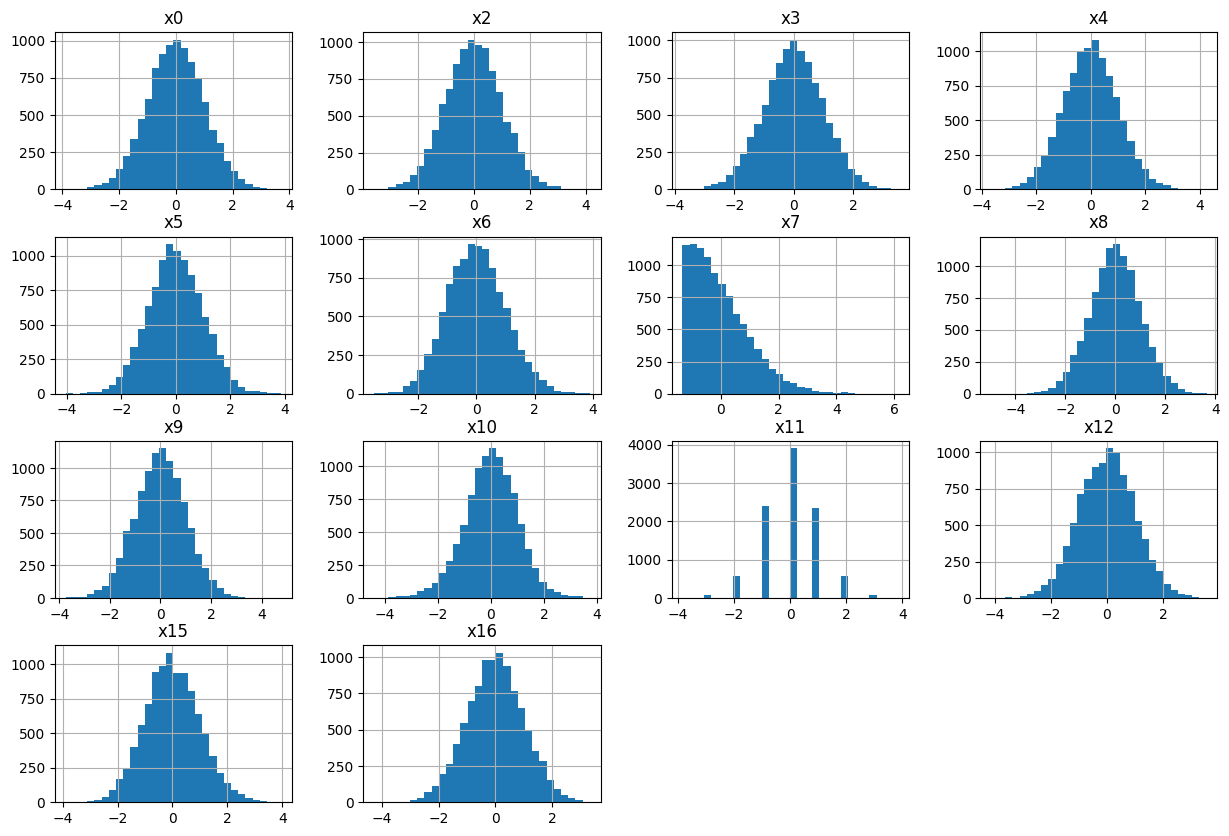

In [17]:
df_clean[cols_to_scale].hist(bins=30, figsize=(15, 10))

#### I used one-hot encoding to change the categorical columns into true and false. Now, there is a new column for every choice (minus one) in each column. The Next cell switches the true and false to binary numbers.

In [18]:
# Convert categorical variables into dummy/indicator variables
df_encoded = pd.get_dummies(df_clean, columns=['x1', 'x13','x14','x17'])

# Verify the new columns
print(df_encoded.head())

         x0        x2        x3        x4        x5        x6        x7  \
0 -0.838931  0.596557 -0.185458 -1.183741 -0.101785  0.077674  0.843704   
1 -1.500596  0.841160 -0.209748 -0.018306  1.001915 -0.946066 -1.283069   
2 -0.212174 -0.921825 -0.047607  0.517776  1.115169  0.650384 -1.140378   
3 -0.693986 -0.248855  0.367838  0.433536 -0.325610  1.314714 -0.785966   
4 -0.367732  0.626554 -0.486784 -1.067796 -0.496945  0.051916  0.689132   

         x8        x9       x10  ...  x13_toyota  x13_volkswagon  x14_friday  \
0 -0.645285 -0.740418  0.068029  ...       False           False       False   
1  1.192171 -0.848392  1.003833  ...        True           False       False   
2 -1.039740 -0.538897  0.844374  ...       False           False       False   
3  0.419124 -0.177167 -0.097857  ...        True           False       False   
4 -0.203043  0.509773 -0.098958  ...       False           False       False   

   x14_monday  x14_thursday  x14_tuesday  x14_wednesday  x17_large  

In [21]:
#Convert all boolean columns (True/False) to integers (1/0)
# Separate features and target
# Assuming 'y' is your target variable column
X = df_clean.drop(columns=['y'])
y = df_clean['y']

X = X.astype({col: int for col in X.select_dtypes('bool').columns})

# Verify the change
print(X.head())

         x0   x1        x2        x3        x4        x5        x6        x7  \
0 -0.838931  jun  0.596557 -0.185458 -1.183741 -0.101785  0.077674  0.843704   
1 -1.500596  jul  0.841160 -0.209748 -0.018306  1.001915 -0.946066 -1.283069   
2 -0.212174  aug -0.921825 -0.047607  0.517776  1.115169  0.650384 -1.140378   
3 -0.693986  aug -0.248855  0.367838  0.433536 -0.325610  1.314714 -0.785966   
4 -0.367732  may  0.626554 -0.486784 -1.067796 -0.496945  0.051916  0.689132   

         x8        x9       x10       x11       x12     x13        x14  \
0 -0.645285 -0.740418  0.068029 -0.956197  0.030482   tesla   thursday   
1  1.192171 -0.848392  1.003833  0.004433 -0.596613  toyota   thursday   
2 -1.039740 -0.538897  0.844374  0.004433 -0.663655     bmw  wednesday   
3  0.419124 -0.177167 -0.097857  0.965063  1.299195  toyota  wednesday   
4 -0.203043  0.509773 -0.098958 -0.956197  0.134347   honda  wednesday   

        x15       x16    x17  
0  0.679520 -0.126194  small  
1  2.451947 

In [22]:
print(df_encoded.columns)

Index(['x0', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11',
       'x12', 'x15', 'x16', 'y', 'x1_apr', 'x1_aug', 'x1_dec', 'x1_feb',
       'x1_jan', 'x1_jul', 'x1_jun', 'x1_mar', 'x1_may', 'x1_nov', 'x1_oct',
       'x1_sep', 'x13_bmw', 'x13_chevrolet', 'x13_chrystler', 'x13_ford',
       'x13_honda', 'x13_mercades', 'x13_nissan', 'x13_tesla', 'x13_toyota',
       'x13_volkswagon', 'x14_friday', 'x14_monday', 'x14_thursday',
       'x14_tuesday', 'x14_wednesday', 'x17_large', 'x17_medium', 'x17_small'],
      dtype='object')


In [23]:
# 1. Isolate the target variable
y = df_encoded['y']

# 2. Isolate the features by dropping the target column
X = df_encoded.drop('y', axis=1)

# 3. Verify the separation
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (9968, 44)
Shape of y (target): (9968,)


In [24]:
from sklearn.model_selection import train_test_split

# Splitting the data: 80% for training the model, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (7974, 44)
Testing features shape: (1994, 44)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# 2. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Compare Results
print("Logistic Regression Results:")
print(classification_report(y_test, log_model.predict(X_test)))

print("\nRandom Forest Results:")
print(classification_report(y_test, rf_model.predict(X_test)))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.52      0.58      0.55      1030
           1       0.48      0.42      0.45       964

    accuracy                           0.50      1994
   macro avg       0.50      0.50      0.50      1994
weighted avg       0.50      0.50      0.50      1994


Random Forest Results:
              precision    recall  f1-score   support

           0       0.53      0.60      0.56      1030
           1       0.50      0.42      0.46       964

    accuracy                           0.51      1994
   macro avg       0.51      0.51      0.51      1994
weighted avg       0.51      0.51      0.51      1994



<Axes: >

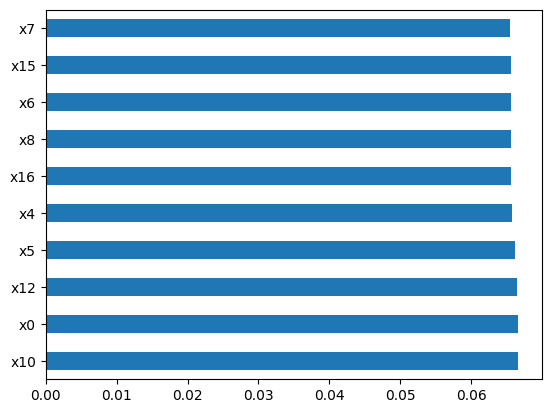

In [26]:
import pandas as pd
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')

### Summary: 
#### This model did not do very well, 51% accuracy isn't much better than a random coin flip. I think it is due to the noise, there are so many variables. Also, since the variables aren't titled I can't use logic to determine what columns have the strongest correlation with y. Based on the visuals graphs it seems that all the columns follow the same distribution.

### Source:
#### I used code snippets from gemini but I revised and used my train of thought throughout the assignment. All the markdown cells are my own. 

# ----------Week 7----------------
### Evaluating Classification Models

#### I am first checking the precision, recall, and f1-score of my model. The results are so low that this model wouldn't perform better than a random coin flip.


In [36]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# 1. Generate a comprehensive report
# This provides precision, recall, and f1-score for each class (0 and 1)
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

# 2. Get individual scores as variables for further analysis or tuning
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.60      0.56      1030
           1       0.50      0.42      0.46       964

    accuracy                           0.51      1994
   macro avg       0.51      0.51      0.51      1994
weighted avg       0.51      0.51      0.51      1994

Precision: 0.4957
Recall: 0.4232
F1-Score: 0.4566


In [41]:
#preparing the models and libraries.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# List of your trained models from the assignment
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model
}

#### In the following cell, I create a confusion matrix to see the amount of true positives, true negatives, false positives, and false negatives. I made a confusion matrix for the Random Forest model as well as the Logistic Regression model.

<Figure size 1000x600 with 0 Axes>

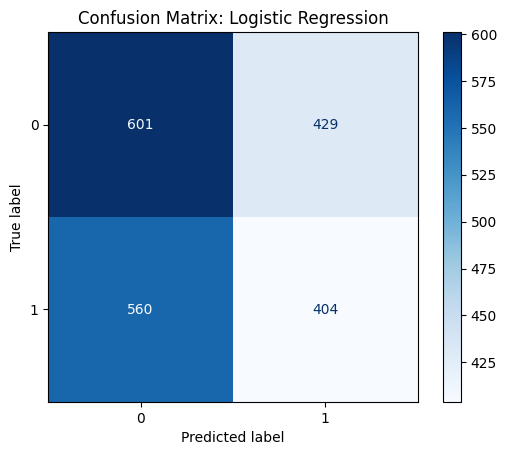

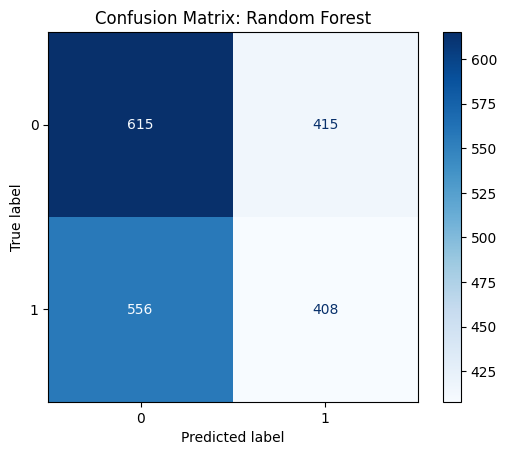

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Dictionary of your models
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model
}

# Generate Confusion Matrices and ROC Curves
plt.figure(figsize=(10, 6))

for name, model in models.items():
    # 1. Confusion Matrix
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    

#### Interesting Observation: The numbers by themselves in the matrix don't mean much, unless you look at the whole picture. It looks right away like so many actuals were predicted correctly (615) but you don't know how many of the are actually positive in reality until you take into account all the numbers in the matrix. 

#### This cell shows the ROC of the two models on the same chart. The ROC is a graph that helps discern what threshold to use.

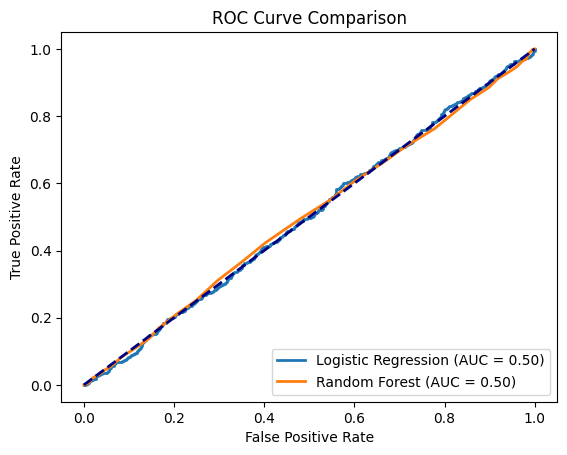

In [39]:
for name, model in models.items():
# 2. ROC and AUC
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Finalize ROC Plot
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

#### I created a AOC chart. An ROC with the area bellow the line filled out. In this way we can compare the two models. Whichever model has more area under it's curve is the better model to use. Both of our AUC's are quite low at 50%.  

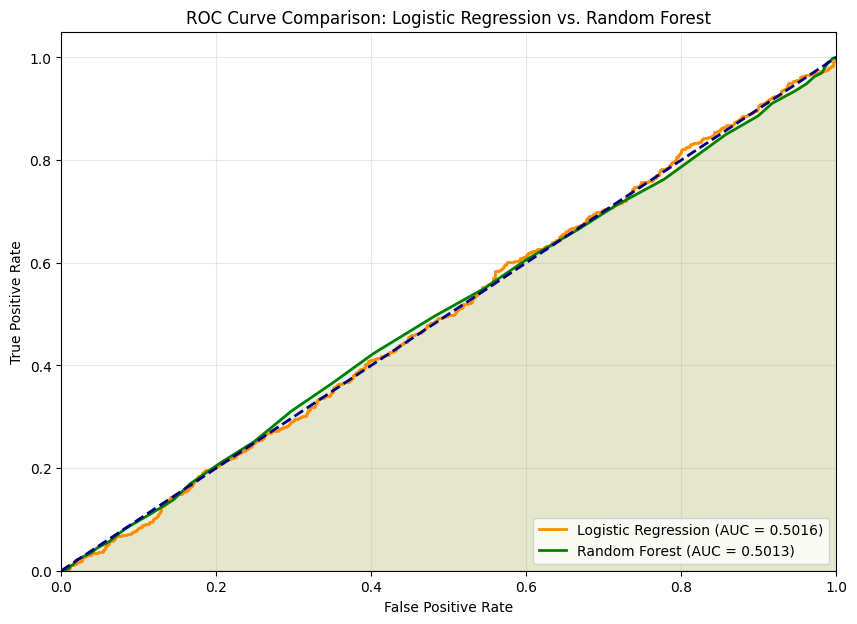

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the positive class for both models
y_probs_log = log_model.predict_proba(X_test)[:, 1]
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# 2. Calculate ROC metrics and AUC for Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
roc_auc_log = auc(fpr_log, tpr_log)

# 3. Calculate ROC metrics and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 4. Plotting
plt.figure(figsize=(10, 7))

# Plot Logistic Regression Curve and fill area
plt.plot(fpr_log, tpr_log, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.4f})')
plt.fill_between(fpr_log, tpr_log, color='darkorange', alpha=0.1)

# Plot Random Forest Curve and fill area
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.fill_between(fpr_rf, tpr_rf, color='green', alpha=0.1)

# Plot the random guess line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Formatting the chart
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Logistic Regression vs. Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### The logistic regression model has an area under the curve of .5016 which is hardly a noticeable difference but greater than the random forest AUC, which is .5013. 

#### Both these models need a lot of help!!

#### In order to improve the model's performance, I will check to see what hyperparmeters to use as a best fit for the models.

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Define the grid of hyperparameters to test (Week 5 technique)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Set up GridSearchCV with 5-fold Cross-Validation
# We use 'f1' as the scoring metric to align with your Week 7 goals
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit the grid search to your training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


#### I am rerunning the models using the "best parameters". 

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model with your optimized parameters
final_model = RandomForestClassifier(
    max_depth=None, 
    min_samples_split=5, 
    n_estimators=50, 
    random_state=42
)

# Train the model on your training set
final_model.fit(X_train, y_train)

# Generate predictions
y_pred = final_model.predict(X_test)

In [49]:
#printing the results
print("Final Model Classification Report:\n")
print(classification_report(y_test, y_pred))



Final Model Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.51      0.51      1030
           1       0.46      0.45      0.46       964

    accuracy                           0.48      1994
   macro avg       0.48      0.48      0.48      1994
weighted avg       0.48      0.48      0.48      1994



In [50]:
#prining a new confusion matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:

[[527 503]
 [527 437]]


#### Even using the "best" parameters the model now performed even lower. It looks like the data set has too much noise for the model to find a proper pattern that predicts y. 

<Axes: >

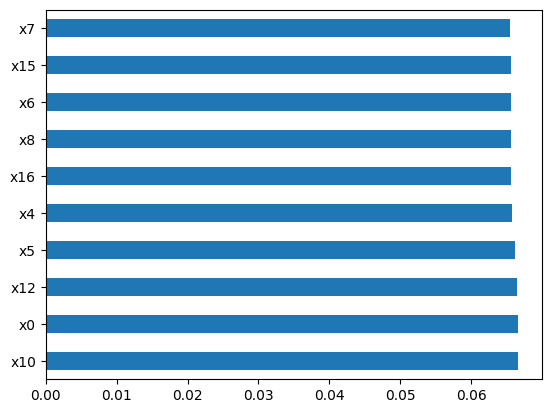

In [51]:
import pandas as pd
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')

### This shows that there is no specific variable that has more of an effect on the prediction. They all are equal, which could be a good reason that they are all treated as noise and the model can't find a pattern.

### Based on the results of this model it seems that there is a very weak correlation, if any, between the variables and y.